# Лабораторная работа №2. Реализация подсчёта треугольников

В ходе ЛР выполнены все задания, включая дополнительные

#### Импорты и их проверка

In [1]:
import graphblas as gb
print("OK")

OK


In [2]:
A = gb.Matrix.from_coo(
    [0, 1],
    [1, 0],
    [1, 1],
    nrows=2,
    ncols=2
)

print(A)

"M_0"      nvals  nrows  ncols  dtype         format
gb.Matrix      2      2      2  INT64  bitmapr (iso)
----------------------------------------------------
   0  1
0     1
1  1   


### Функции для быстрого тестирования подсчета треугольников

In [3]:
def create_test_graph_1():
    """Возвращает обхект graphblas для графа-треугольника"""
    rows = [0, 1, 2, 0, 1, 2]
    cols = [1, 2, 0, 2, 0, 1]
    vals = [1] * 6
    
    return gb.Matrix.from_coo(rows, cols, vals, nrows=3, ncols=3)

def create_test_graph_2():
    """Возвращает обхект graphblas для графа без треугольников"""
    rows = [0, 1, 1, 2]
    cols = [1, 0, 2, 1]
    vals = [1] * 4
    
    return gb.Matrix.from_coo(rows, cols, vals, nrows=3, ncols=3)

In [4]:
def test_func(triangles_counter_func):
    """Проверяет функцию подсчета треугольников в графе двумя простыми тестами"""
    test_graph_1 = create_test_graph_1()
    test_graph_2 = create_test_graph_2()
    
    assert triangles_counter_func(test_graph_1) == 1
    assert triangles_counter_func(test_graph_2) == 0
    
    print("OK")

## Функция и проверка подсчета метдом А^3

In [5]:
def count_triangles_A3(A: gb.Matrix) -> int:
    """
    Подсчёт числа треугольников через A^3. Принимает граф-объект graphblas, выдает кол-во треугольников.
    """
    
    A3 = A.mxm(A).mxm(A)
    trace = A3.diag().reduce().new().value
    
    if trace is None:
        return 0
    
    triangles = trace // 6

    return int(triangles)

In [6]:
test_func(count_triangles_A3)

OK


## Функция и проверка подсчета метдом А^2 + маска

In [7]:
def count_triangles_A2_mask(A: gb.Matrix) -> int:
    """
    Подсчёт числа треугольников через A^2 с маской. Принимает граф-объект graphblas, выдает кол-во треугольников.
    """
    C = A.mxm(A).dup(mask=A.dup(dtype=bool))
    
    total = C.reduce_scalar().value
    
    if total is None:
        return 0

    return int(total // 6)

In [8]:
test_func(count_triangles_A2_mask)

OK


## Функция и проверка подсчета метдом Сohen's algorithm

In [9]:
def count_triangles_cohen(A: gb.Matrix) -> int:
    """
    Подсчёт треугольников методом Cohen. Принимает граф-объект graphblas, выдает кол-во треугольников.
    """
    
    L = gb.select.tril(A)
    U = gb.select.triu(A)
    
    C = L.mxm(U).dup(mask=A.dup(dtype=bool))
    
    total = C.reduce_scalar().value

    if total is None:
        return 0
        
    return int(total // 2)

In [10]:
test_func(count_triangles_cohen)

OK


## Функция и проверка подсчета метдом Sandia algorithm

In [11]:
def count_triangles_sandia(A: gb.Matrix) -> int:
    """
    Подсчёт треугольников методом Sandia. Принимает граф-объект graphblas, выдает кол-во треугольников.
    """
    
    L = gb.select.tril(A)
    
    C = L.mxm(L).dup(mask=L.dup(dtype=bool))
    
    # суммируем
    total = C.reduce_scalar().value or 0
    
    return int(total)

In [12]:
test_func(count_triangles_sandia)

OK


## Тестриование всех влгоритмов

### Генерация тестовых графов

In [13]:
import numpy as np


def numpy_to_graphblas(A: np.ndarray) -> gb.Matrix:
    rows, cols = np.nonzero(A)
    vals = A[rows, cols]
    n = A.shape[0]
    return gb.Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n)


def generate_test_cases():
    test_cases = []

    # 1. Один треугольник
    A = np.array([
        [0,1,1],
        [1,0,1],
        [1,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), 1, "Один треугольник"))

    # 2. Цепочка (0)
    A = np.array([
        [0,1,0],
        [1,0,1],
        [0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), 0, "Цепочка"))

    # 3. Квадрат без диагоналей
    A = np.array([
        [0,1,0,1],
        [1,0,1,0],
        [0,1,0,1],
        [1,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), 0, "Квадрат без диагоналей"))

    # 4. Квадрат с одной диагональю
    A = np.array([
        [0,1,1,1],
        [1,0,1,0],
        [1,1,0,1],
        [1,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), 2, "Квадрат с одной диагональю"))

    # 5. Полный граф 4 вершины
    A = np.ones((4,4)) - np.eye(4)
    test_cases.append((numpy_to_graphblas(A), 4, "Полный граф 4 вершины"))

    # 6. Полный граф 5 вершин
    A = np.ones((5,5)) - np.eye(5)
    test_cases.append((numpy_to_graphblas(A), 10, "Полный граф 5 вершин"))

    # 7. Две несвязанные тройки
    A = np.zeros((6,6))
    edges = [(0,1),(1,2),(2,0),(3,4),(4,5),(5,3)]
    for i,j in edges:
        A[i,j] = A[j,i] = 1
    test_cases.append((numpy_to_graphblas(A), 2, "Две несвязанные тройки"))

    # 8. Звезда
    A = np.zeros((5,5))
    for i in range(1,5):
        A[0,i] = A[i,0] = 1
    test_cases.append((numpy_to_graphblas(A), 0, "Звезда"))

    # 9. Один треугольник + отдельная вершина
    A = np.array([
        [0,1,1,0],
        [1,0,1,0],
        [1,1,0,1],
        [0,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), 1, "Один треугольник + отдельная вершина"))

    # 10. Пустой граф
    A = np.zeros((4,4))
    test_cases.append((numpy_to_graphblas(A), 0, "Пустой граф"))

    return test_cases

### Фунция тестирования

In [14]:
def run_triangle_tests(triangle_func):
    test_cases = generate_test_cases()
    
    for i, (A, expected, name) in enumerate(test_cases):
        result = triangle_func(A)
        
        assert result == expected, (
            f"Тест {name} упал: {expected} != {result}"
        )
    
    print(f"{triangle_func.__name__} -- все тесты пройдены!")

### Прогоняем тесты для всех функций

In [15]:
run_triangle_tests(count_triangles_A3)
run_triangle_tests(count_triangles_A2_mask)
run_triangle_tests(count_triangles_cohen)
run_triangle_tests(count_triangles_sandia)

count_triangles_A3 -- все тесты пройдены!
count_triangles_A2_mask -- все тесты пройдены!
count_triangles_cohen -- все тесты пройдены!
count_triangles_sandia -- все тесты пройдены!


## Доп. задание -- посчет кол-ва треугольников для каждой вершины

### Функция подсчета треугольников для каждой вершины 

In [16]:
def triangles_per_vertex(A: gb.Matrix):
    """
    Возвращает gb.Vector:
    для каждой вершины — число треугольников
    """
    
    C = A.mxm(A).dup(mask=A.dup(dtype=bool))
    v = C.reduce_rowwise().new()

    v = v.apply(lambda x: x // 2)
    
    return v

### Дополненные тесты для каждой вершины

In [17]:
def generate_vertex_test_cases():
    test_cases = []

    # 1. Один треугольник
    A = np.array([
        [0,1,1],
        [1,0,1],
        [1,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), [1,1,1], "Один треугольник"))

    # 2. Цепочка
    A = np.array([
        [0,1,0],
        [1,0,1],
        [0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), [0,0,0], "Цепочка"))

    # 3. Квадрат без диагоналей
    A = np.array([
        [0,1,0,1],
        [1,0,1,0],
        [0,1,0,1],
        [1,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), [0,0,0,0], "Квадрат без диагоналей"))

    # 4. Квадрат с диагональю
    A = np.array([
        [0,1,1,1],
        [1,0,1,0],
        [1,1,0,1],
        [1,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), [2,1,2,1], "Квадрат с одной диагональю"))

    # 5. Полный граф 4 вершины
    A = np.ones((4,4)) - np.eye(4)
    test_cases.append((numpy_to_graphblas(A), [3,3,3,3], "Полный граф 4 вершины"))

    # 6. Полный граф 5 вершин
    A = np.ones((5,5)) - np.eye(5)
    test_cases.append((numpy_to_graphblas(A), [6,6,6,6,6], "Полный граф 5 вершин"))

    # 7. Две тройки
    A = np.zeros((6,6))
    edges = [(0,1),(1,2),(2,0),(3,4),(4,5),(5,3)]
    for i,j in edges:
        A[i,j] = A[j,i] = 1
    test_cases.append((numpy_to_graphblas(A), [1,1,1,1,1,1], "Две несвязанные тройки"))

    # 8. Звезда
    A = np.zeros((5,5))
    for i in range(1,5):
        A[0,i] = A[i,0] = 1
    test_cases.append((numpy_to_graphblas(A), [0,0,0,0,0], "Звезда"))

    # 9. Один треугольник + отдельная вершина
    A = np.array([
        [0,1,1,0],
        [1,0,1,0],
        [1,1,0,1],
        [0,0,1,0]
    ])
    test_cases.append((numpy_to_graphblas(A), [1,1,1,0], "Один треугольник + отдельная вершина"))

    # 10. Пустой граф
    A = np.zeros((4,4))
    test_cases.append((numpy_to_graphblas(A), [0,0,0,0], ""))

    return test_cases

### Функция тестирования

In [18]:
def run_vertex_tests(func):
    test_cases = generate_vertex_test_cases()
    
    for i, (A, expected, name) in enumerate(test_cases):
        result = func(A)
        
        # переводим в список
        result_list = [result.get(i, 0) or 0 for i in range(A.nrows)]
        
        assert result_list == expected, (
           f"Тест {name} упал: {expected} != {result}"
        )
    
    print(f"{func.__name__} -- все тесты пройдены!")

### Прогоняем тесты

In [19]:
run_vertex_tests(triangles_per_vertex)

triangles_per_vertex -- все тесты пройдены!


Все тесты пройдены, функция работает правильно.

## Доп. задание -- проверка на графах из SuiteSparse Matrix Collection  

### Функция считываания матриц из .mtx файла

Загрузил больше 10 файлов для большего разнообразия графов

In [20]:
from scipy.io import mmread


def load_graphblas_from_mtx(path: str) -> gb.Matrix:
    """
    Загружает .mtx файл по пути path в graphblas.Matrix
    """
    M = mmread(path).tocsr()
    
    rows, cols = M.nonzero()
    vals = M.data
    
    n = M.shape[0]
    
    A = gb.Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n)
    A = A - gb.Matrix.diag(A.diag())
    
    return A

### Функция засекания времени

In [21]:
import time

def measure_time(func, A):
    start = time.perf_counter()
    result = func(A)
    end = time.perf_counter()
    
    return end - start, result

### Список всех фунгкций алгоритмов

In [22]:
ALGORITHMS = [
    count_triangles_A3,
    count_triangles_A2_mask,
    count_triangles_cohen,
    count_triangles_sandia
]

### Функция прогона всех алгоритмов на всех загруженных матрицах и выгрузки результатов в датафрейм

In [23]:
import os
import pandas as pd

def benchmark_all_graphs(graphs_dir: str):
    """
    Прогоняет все алгоритмы по всем графам в папке
    и возвращает pandas DataFrame с результататтами
    """
    
    records = []
    
    for filename in os.listdir(graphs_dir):
        if not filename.endswith(".mtx"):
            continue
        
        path = os.path.join(graphs_dir, filename)
        
        print(filename)
        
        # загрузка графа
        A = load_graphblas_from_mtx(path)
        
        n = A.nrows
        nnz = A.nvals
        
        for func in ALGORITHMS:
            time_spent, triangles = measure_time(func, A)
            
            records.append({
                "graph": filename,
                "algorithm": func.__name__,
                "n_vertices": n,
                "n_edges": nnz // 2,   # т.к. граф неориентированный
                "nnz": nnz,
                "triangles": triangles,
                "time_sec": time_spent
            })
    
    df = pd.DataFrame(records)
    
    return df

### Прогоняем все алгоритмы по всем матрицам и получаем результаты

In [24]:
df = benchmark_all_graphs("Graph Analysis/Lab2/graphs/")
df.head()

ca-GrQc.mtx
dblp-2010.mtx
delaunay_n14.mtx
delaunay_n15.mtx
delaunay_n24.mtx
email.mtx
fxm3_6.mtx
italy_osm.mtx
mycielskian10.mtx
NACA0015.mtx
net25.mtx
opt1.mtx
rajat06.mtx
vsp_data_and_seymourl.mtx
wing_nodal.mtx


,graph,algorithm,n_vertices,n_edges,nnz,triangles,time_sec
0,ca-GrQc.mtx,count_triangles_A3,5242,14490,28980,48260,0.008164
1,ca-GrQc.mtx,count_triangles_A2_mask,5242,14490,28980,48260,0.001547
2,ca-GrQc.mtx,count_triangles_cohen,5242,14490,28980,48260,0.001611
3,ca-GrQc.mtx,count_triangles_sandia,5242,14490,28980,48260,0.000908
4,dblp-2010.mtx,count_triangles_A3,326186,807700,1615400,1676652,0.487407


### Проверяем, что все алгоритмы выдали одинаковый ответ

In [25]:
check = df.groupby("graph")["triangles"].nunique()
    

if len(check[check > 1]) != 0:
    print("АЛГОРИТМЫ ВЫДАЮТ РАЗНОЕ КОЛ_ВО ТРЕУГОЛЬНИКОВ")
    raise Exception("АЛГОРИТМЫ ВЫДАЮТ РАЗНОЕ КОЛ_ВО ТРЕУГОЛЬНИКОВ")
else:
    print("ОК")

ОК


### Визуализируем

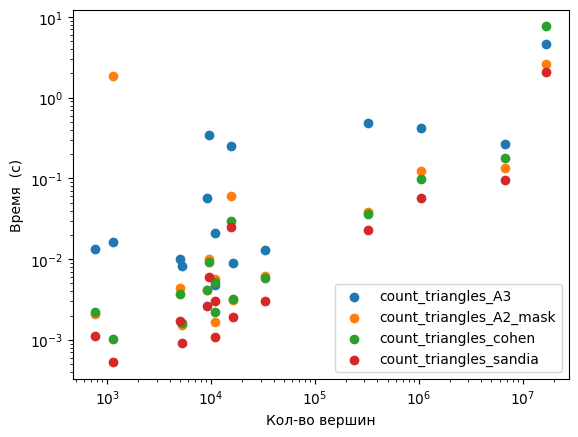

In [26]:
import matplotlib.pyplot as plt

for algo in df["algorithm"].unique():
    subset = df[df["algorithm"] == algo]
    
    plt.scatter(subset["n_vertices"], subset["time_sec"], label=algo)

plt.xlabel("Кол-во вершин")
plt.ylabel("Время  (с)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

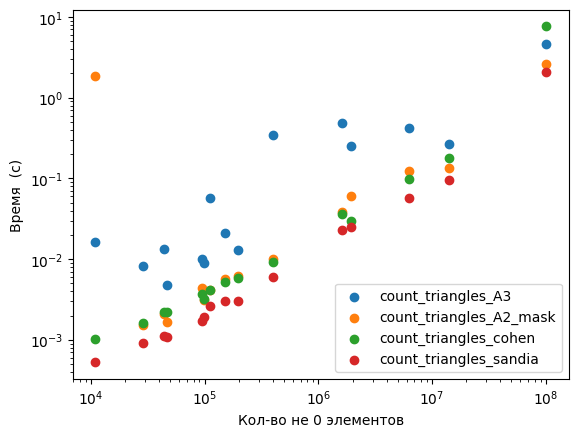

In [27]:
for algo in df["algorithm"].unique():
    subset = df[df["algorithm"] == algo]
    
    plt.scatter(subset["nnz"], subset["time_sec"], label=algo)

plt.xlabel("Кол-во не 0 элементов")
plt.ylabel("Время  (с)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

### Смотрим разреженность графов

In [28]:
df['edge_share'] = df['n_edges'] / (df['n_vertices'] * (df['n_vertices'] - 1) // 2)

df.sort_values(by='nnz', ascending=False)

,graph,algorithm,n_vertices,n_edges,nnz,triangles,time_sec,edge_share
16,delaunay_n24.mtx,count_triangles_A3,16777216,50331601,100663202,33746670,4.590722,3.576276e-07
17,delaunay_n24.mtx,count_triangles_A2_mask,16777216,50331601,100663202,33746670,2.645619,3.576276e-07
18,delaunay_n24.mtx,count_triangles_cohen,16777216,50331601,100663202,33746670,7.662633,3.576276e-07
19,delaunay_n24.mtx,count_triangles_sandia,16777216,50331601,100663202,33746670,2.077764,3.576276e-07
31,italy_osm.mtx,count_triangles_sandia,6686493,7013978,14027956,7410,0.094872,3.137601e-07
30,italy_osm.mtx,count_triangles_cohen,6686493,7013978,14027956,7410,0.177308,3.137601e-07
29,italy_osm.mtx,count_triangles_A2_mask,6686493,7013978,14027956,7410,0.132767,3.137601e-07
28,italy_osm.mtx,count_triangles_A3,6686493,7013978,14027956,7410,0.267501,3.137601e-07
36,NACA0015.mtx,count_triangles_A3,1039183,3114818,6229636,2075635,0.418533,5.768714e-06
37,NACA0015.mtx,count_triangles_A2_mask,1039183,3114818,6229636,2075635,0.125129,5.768714e-06


### Выводы

В целом результаты предсказуемые -- время растет со степенной зависимостью от кол-ва вершин и не 0 элементов.

Среди алгоритмов также логичны результаты: A3 алгоритм сильно проигрывает остальным, на третьем месте A2 алгоритм с маской, на втором месте Cohen алгоритми на первом алгоритм Sandia

Однако, на двух самых больших графаф алгоитм Cohen проигрывает всем остальным. Это может быть связано с очень сильно разреженностью этих графов, что показано в таблице выше.

## Доп задание -- генератор случайных графов и исследование алгоритмов

### Функция генерации случайного графа

* Из-за зависимостей не получилось достать нужный метод сделать генератор как на практике сразу из библиотеки, поэтому написал свой.
* За размер отвечает параметр n, а за разреженность параметр p.
* Генератор может падать из-за недостатка оперативки (чаще всего при переходе к формату из gb, т.к. хранит вектор слишком большой длины). Такие случаи обрабатываются и не будут учитываться в будущем

In [29]:
def generate_random_graph(n: int, p: float, seed=None, batch_size=1_000_000):
    """
    Принимает кол-во вершин n и вероятность возникновения ребра p.
    Возвращает неоритиированный граф в формате gb.Matrix
    """
    try:
        rng = np.random.default_rng(seed)
        
        # ожидаемое число рёбер
        max_edges = n * (n - 1) // 2
        expected_edges = int(max_edges * p)
        
        rows = []
        cols = []
        
        generated = 0
        
        while generated < expected_edges:
            size = min(batch_size, expected_edges - generated)
            
            i = rng.integers(0, n, size=size, dtype=np.int64)
            j = rng.integers(0, n, size=size, dtype=np.int64)
            
            # убираем петли
            mask = i != j
            i = i[mask]
            j = j[mask]
            
            # берём только i < j (верхний треугольник)
            mask = i < j
            i = i[mask]
            j = j[mask]
            
            rows.append(i)
            cols.append(j)
            
            generated += len(i)
        
        # объединяем
        rows = np.concatenate(rows)
        cols = np.concatenate(cols)
        
        # делаем симметричным
        rows_full = np.concatenate([rows, cols])
        cols_full = np.concatenate([cols, rows])
        
        # создаём sparse матрицу
        A = gb.Matrix.from_coo(
            rows_full,
            cols_full,
            [1] * len(rows_full),
            nrows=n,
            ncols=n,
            dup_op=gb.binary.max
        )

        return A
    except Exception as e:
        print(f"Не удалось создать матрицу {n} вершин с вероятностью {p}, ошибка: {type(e).__name__}")
    

### Проверка генератора

In [30]:
generate_random_graph(10, 0.2)

"M_466"    nvals  nrows  ncols  dtype         format
gb.Matrix     18     10     10  INT64  bitmapr (iso)
----------------------------------------------------
   0 1  2  3  4  5  6  7  8  9
0                         1   
1                             
2          1                  
3       1     1              1
4          1        1         
5                      1      
6             1        1  1   
7                1  1         
8  1                1        1
9          1              1

### Функция подсчета времени работы и получения результатов для разных алгоритмов посчета треугольников

Трешхолды подбирались оптыным путем, чтобы запуск занимал в сумме менее 20 минут.

In [31]:
import pandas as pd
import time


def benchmark_random_graphs(n_values, p_values, a3_edges_treshold=600_000, a2_edges_threshhold=40_000_000
                               , cohen_edges_threshhold=95_000_000, sandia_edges_threshhold=175_000_000):
    """
    Получает на вход список кол-ва вершин, список вероятностей возникновения ребер 
    и список трешхолдов для каждого алгоритма подсчета треугольников, чтобы работать разумное кол-во времени.
    Если кол-во ребер больше трешхолда, то алгоритму приписывается время работы в 30 секнуд.

    Возвращает датафрейм со статистиками работы каждого алгоритма
    """
    
    records = []
    
    for n in n_values:
        for p in p_values:
            
            A = generate_random_graph(n, p, seed=42)
            if A is None:
                continue
            
            nnz = A.nvals
            
            for func in ALGORITHMS:
                cnt_edges = n * (n - 1) // 2 * p
                if (func.__name__ == "count_triangles_A3" and cnt_edges > a3_edges_treshold
                    or func.__name__ == "count_triangles_A2_mask" and cnt_edges > a2_edges_threshhold
                    or func.__name__ == "count_triangles_cohen" and cnt_edges > cohen_edges_threshhold
                    or func.__name__ == "count_triangles_sandia" and cnt_edges > sandia_edges_threshhold):
                
                    records.append({
                        "n_vertices": n,
                        "p": p,
                        "nnz": nnz,
                        "algorithm": func.__name__,
                        "triangles": -1,
                        "time_sec": 30
                    })
                    print(f"n={n}, p={p}, {func.__name__}, skip")
                    continue

                start = time.perf_counter()
                try:
                    triangles = func(A)
                except Exception as e:
                    print(f"n={n}, p={p}, {func.__name__}, упали с ошибкой {type(e).__name__}")
                    continue
                end = time.perf_counter()
                
                records.append({
                    "n_vertices": n,
                    "p": p,
                    "nnz": nnz,
                    "algorithm": func.__name__,
                    "triangles": triangles,
                    "time_sec": end - start
                })

                print(f"n={n}, p={p}, {func.__name__}, time: {(end - start):.3f}")
    
    return pd.DataFrame(records)

### Списки кол-ва вершин и вероятности ребер

In [32]:
n_values =  np.logspace(np.log10(500), np.log10(600_000), 15).astype(int)
p_values = [0.0001, 0.001, 0.01, 0.1] #+ np.linspace(0.15, 0.5, 3).tolist()

n_values, p_values

(array([   499,    829,   1376,   2284,   3790,   6290,  10438,  17320,
         28741,  47691,  79138, 131318, 217905, 361584, 600000]),
 [0.0001, 0.001, 0.01, 0.1])

### Запускаем все алгоритмы на всех параметрах

Некоторые запуски падают на этапе создания матрицы из-за нехватки оперативы, некторорые запуски падают по той же причине, но уже при возведении матрицы в степень. Такие запуски не учитываются в результатах

In [33]:
df_rand = benchmark_random_graphs(n_values, p_values)

n=499, p=0.0001, count_triangles_A3, time: 0.003
n=499, p=0.0001, count_triangles_A2_mask, time: 0.002
n=499, p=0.0001, count_triangles_cohen, time: 0.000
n=499, p=0.0001, count_triangles_sandia, time: 0.001
n=499, p=0.001, count_triangles_A3, time: 0.000
n=499, p=0.001, count_triangles_A2_mask, time: 0.000
n=499, p=0.001, count_triangles_cohen, time: 0.000
n=499, p=0.001, count_triangles_sandia, time: 0.000
n=499, p=0.01, count_triangles_A3, time: 0.001
n=499, p=0.01, count_triangles_A2_mask, time: 0.000
n=499, p=0.01, count_triangles_cohen, time: 0.000
n=499, p=0.01, count_triangles_sandia, time: 0.000
n=499, p=0.1, count_triangles_A3, time: 0.006
n=499, p=0.1, count_triangles_A2_mask, time: 0.002
n=499, p=0.1, count_triangles_cohen, time: 0.001
n=499, p=0.1, count_triangles_sandia, time: 0.001
n=829, p=0.0001, count_triangles_A3, time: 0.000
n=829, p=0.0001, count_triangles_A2_mask, time: 0.000
n=829, p=0.0001, count_triangles_cohen, time: 0.000
n=829, p=0.0001, count_triangles_sand

In [34]:
df_rand

,n_vertices,p,nnz,algorithm,triangles,time_sec
0,499,0.0001,24,count_triangles_A3,0,0.002811
1,499,0.0001,24,count_triangles_A2_mask,0,0.002489
2,499,0.0001,24,count_triangles_cohen,0,0.000285
3,499,0.0001,24,count_triangles_sandia,0,0.000861
4,499,0.0010,248,count_triangles_A3,1,0.000391
...,...,...,...,...,...,...
211,600000,0.0001,35998148,count_triangles_sandia,35894,0.217764
212,600000,0.0010,359819130,count_triangles_A3,-1,30.000000
213,600000,0.0010,359819130,count_triangles_A2_mask,-1,30.000000
214,600000,0.0010,359819130,count_triangles_cohen,-1,30.000000


### Проверяем, что все алгоритмы выдали одно кол-во треугольников на одинаковые кейсы

In [35]:
check = df_rand[df_rand['triangles'] != -1].groupby(["n_vertices", "p", "nnz"])["triangles"].nunique()
    

if len(check[check > 1]) != 0:
    print("АЛГОРИТМЫ ВЫДАЮТ РАЗНОЕ КОЛ_ВО ТРЕУГОЛЬНИКОВ")
    raise Exception("АЛГОРИТМЫ ВЫДАЮТ РАЗНОЕ КОЛ_ВО ТРЕУГОЛЬНИКОВ")
else:
    print("ОК")

ОК


### Визуализация

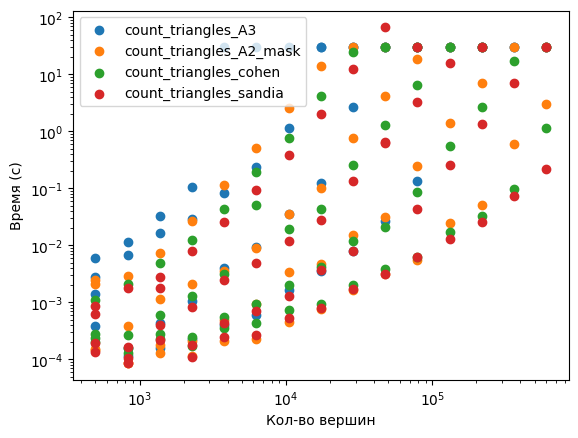

In [36]:
for algo in df_rand["algorithm"].unique():
    subset = df_rand[df_rand["algorithm"] == algo]
    
    plt.scatter(subset["n_vertices"], subset["time_sec"], marker='o', label=algo)

plt.xlabel("Кол-во вершин")
plt.ylabel("Время (с)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

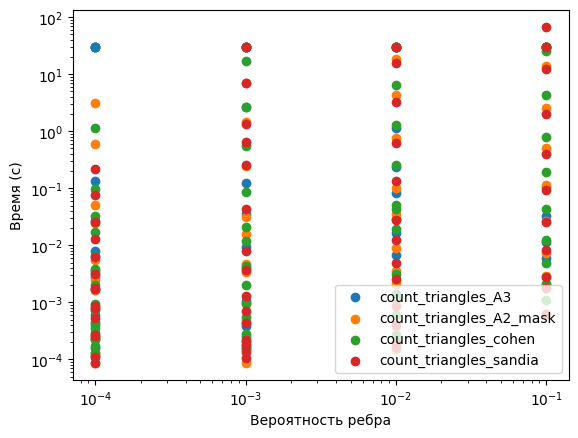

In [37]:
for algo in df_rand["algorithm"].unique():
    subset = df_rand[df_rand["algorithm"] == algo]
    
    plt.scatter(subset["p"], subset["time_sec"], label=algo)

plt.xlabel("Вероятность ребра")
plt.ylabel("Время (с)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

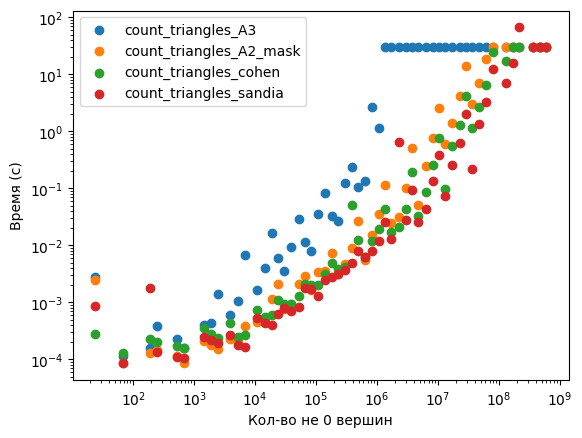

In [38]:
for algo in df_rand["algorithm"].unique():
    subset = df_rand[df_rand["algorithm"] == algo]
    
    plt.scatter(subset["nnz"], subset["time_sec"], marker='o', label=algo)

plt.xlabel("Кол-во не 0 вершин")
plt.ylabel("Время (с)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

### Выводы

* Время работы растет как степенная функция с увеличением числа вершин и вероятности ребер (= числа не 0 элементов в матрице).
* Алгоритмы выстроились по скорости работы также, как при тесте на графах с сайта. Худший A^3 алгоритм, лучший Sandia, при чем результаты Sandia сопоставимы с результатами A^3 при 10 кратном уменьшении кол-ва ребер.
* Границы применимости:
  * A^3 начинает долго считаться при 10^6 ненулевых элементов матрицы
  * A^2 с маской примерно при 10^7 ненулевых элементов
  * Cohen при 10^8
  * Sandia при более чем 10^8
* Наибольшее влияение по графикам на время оказвает именно кол-во ненулевых элементов, а не кол-во вершин (степенная функция резче), что является логичным следвтем представления матриц смежности в формате COO

Полученные границы применимости условны, их можно было бы расширить на более скоростном железе с использованием GPU. Но общую зависимость алгоритмов от показателей графа они улавливают.